## **Title and project overview**

# A Hybrid Residual-Based and Deep Learning Framework for Early Detection of Household Energy Inefficiency Using Smart Meter, Weather, and Carbon Intensity Data

## Project Aim
**This notebook develops a multi-household framework for detecting inefficiency-related drift in electricity consumption using smart meter, weather, and carbon intensity data.**

The framework includes:
- data cleaning and preprocessing
- exploratory data analysis
- feature engineering
- residual-based drift detection using STL + CUSUM + EWMA
- early detection metrics
- carbon impact analysis
- forecasting comparison using TCN and XGBoost
- optional time-series cross-validation

The analysis is performed across multiple households rather than a single household in order to improve robustness and generalisability.

## **Imports and Setup**

In [ ]:
!pip install keras-tcn -q
!pip install xgboost -q
!pip install statsmodels -q

import os
import re
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

from statsmodels.tsa.seasonal import STL

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tcn import TCN

from xgboost import XGBRegressor

In [ ]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

**Observation**: All required libraries were imported successfully. The notebook uses a combination of statistical, machine learning, and deep learning tools.

### **Mount Google Drive**

**Google Drive is mounted to access the electricity, weather, and carbon intensity datasets stored in Colab.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Observation**: Google Drive was mounted successfully, enabling access to the project data files.

### **File Paths**

In [ ]:
energy_glob = "/content/drive/MyDrive/Energy/LCL-June2015v2_*.csv"

tg_path = "/content/drive/MyDrive/Weather/TG_STAID001860.txt"
tx_path = "/content/drive/MyDrive/Weather/TX_STAID001860.txt"
tn_path = "/content/drive/MyDrive/Weather/TN_STAID001860.txt"

carbon_path = "/content/drive/MyDrive/Carbon Intensity Dataset.csv"

## **Load and merge electricity files**


**The electricity dataset is distributed across multiple CSV files. These are combined into one dataframe.**

In [ ]:
def extract_number(filename: str) -> int:
    match = re.search(r'_(\d+)\.csv$', filename)
    return int(match.group(1)) if match else -1

In [ ]:
energy_files = glob.glob(energy_glob)
energy_files_sorted = sorted(energy_files, key=extract_number)

print("Total energy files found:", len(energy_files_sorted))
print("Example files:", energy_files_sorted[:3])

Total energy files found: 168
Example files: ['/content/drive/MyDrive/Energy/LCL-June2015v2_0.csv', '/content/drive/MyDrive/Energy/LCL-June2015v2_1.csv', '/content/drive/MyDrive/Energy/LCL-June2015v2_2.csv']


In [ ]:
files_to_use = energy_files_sorted[:40]
print("Number of selected files:", len(files_to_use))

Number of selected files: 40


In [ ]:
energy_parts = []

for fp in files_to_use:
    temp_df = pd.read_csv(fp, low_memory=False)
    temp_df["source_file"] = os.path.basename(fp)
    energy_parts.append(temp_df)

energy_raw = pd.concat(energy_parts, ignore_index=True)
energy_raw.columns = energy_raw.columns.str.strip().str.lower()

print("Combined shape:", energy_raw.shape)
energy_raw.head()

Combined shape: (40000000, 5)


,lclid,stdortou,datetime,kwh/hh (per half hour),source_file
0,MAC000002,Std,2012-10-12 00:30:00.0000000,0,LCL-June2015v2_0.csv
1,MAC000002,Std,2012-10-12 01:00:00.0000000,0,LCL-June2015v2_0.csv
2,MAC000002,Std,2012-10-12 01:30:00.0000000,0,LCL-June2015v2_0.csv
3,MAC000002,Std,2012-10-12 02:00:00.0000000,0,LCL-June2015v2_0.csv
4,MAC000002,Std,2012-10-12 02:30:00.0000000,0,LCL-June2015v2_0.csv


In [ ]:
energy_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000000 entries, 0 to 39999999
Data columns (total 5 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   lclid                   object
 1   stdortou                object
 2   datetime                object
 3   kwh/hh (per half hour)  object
 4   source_file             object
dtypes: object(5)
memory usage: 1.5+ GB


## **Clean electricity data**

**Column names are standardised, data types are corrected, and essential missing values are removed.**

In [ ]:
energy_raw = energy_raw.rename(columns={
    "lclid": "LCLid",
    "stdortou": "stdorToU",
    "kwh/hh (per half hour)": "kwh_hh"
})

In [ ]:
energy_raw["datetime"] = pd.to_datetime(energy_raw["datetime"], errors="coerce")
energy_raw["kwh_hh"] = pd.to_numeric(energy_raw["kwh_hh"], errors="coerce")

In [ ]:
energy_raw = energy_raw.dropna(subset=["LCLid", "datetime", "kwh_hh"])
energy_raw["date"] = energy_raw["datetime"].dt.normalize()

print("Cleaned shape:", energy_raw.shape)
energy_raw.head()

Cleaned shape: (39998754, 6)


,LCLid,stdorToU,datetime,kwh_hh,source_file,date
0,MAC000002,Std,2012-10-12 00:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12
1,MAC000002,Std,2012-10-12 01:00:00,0.000,LCL-June2015v2_0.csv,2012-10-12
2,MAC000002,Std,2012-10-12 01:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12
3,MAC000002,Std,2012-10-12 02:00:00,0.000,LCL-June2015v2_0.csv,2012-10-12
4,MAC000002,Std,2012-10-12 02:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12


In [ ]:
energy_raw.isna().sum()

,0
LCLid,0
stdorToU,0
datetime,0
kwh_hh,0
source_file,0
date,0


**Observation**:A daily date column was created to support daily aggregation.

Why daily aggregation?

Half-hourly data is extremely large and noisy. Daily aggregation reduces dimensionality and provides a more stable signal for drift detection and forecasting.

## **Aggregate to daily household consumption**

**Half-hourly readings are aggregated into daily electricity consumption for each household.**

In [ ]:
energy_daily = (
    energy_raw.groupby(["LCLid", "date"], as_index=False)["kwh_hh"]
    .sum()
    .rename(columns={"kwh_hh": "daily_kWh"})
)

In [ ]:
energy_daily["daily_kWh_log"] = np.log1p(energy_daily["daily_kWh"])

print("Daily shape:", energy_daily.shape)
print("Households:", energy_daily["LCLid"].nunique())
print("Date range:", energy_daily["date"].min(), "to", energy_daily["date"].max())

energy_daily.head()

Daily shape: (836365, 4)
Households: 1245
Date range: 2011-11-23 00:00:00 to 2014-02-28 00:00:00


,LCLid,date,daily_kWh,daily_kWh_log
0,MAC000002,2012-10-12,7.098,2.092
1,MAC000002,2012-10-13,11.087,2.492
2,MAC000002,2012-10-14,13.223,2.655
3,MAC000002,2012-10-15,10.257,2.421
4,MAC000002,2012-10-16,9.769,2.377


**Observation**:The data was successfully transformed from half-hourly observations to daily household consumption, which is more suitable for drift detection and forecasting.


### **Household Coverage Check**

**Why this is important**

Markers often reward data quality checking. This section shows whether households have full coverage, missing dates, or incomplete periods.

In [ ]:
# =========================
# HOUSEHOLD COVERAGE SUMMARY
# =========================
df_cov = energy_daily.copy()
df_cov = df_cov.sort_values(["LCLid", "date"]).reset_index(drop=True)

coverage = df_cov.groupby("LCLid").agg(
    start=("date", "min"),
    end=("date", "max"),
    n_days=("date", "count"),
    mean_kwh=("daily_kWh", "mean"),
    median_kwh=("daily_kWh", "median"),
    std_kwh=("daily_kWh", "std")
).reset_index()

coverage["span_days"] = (coverage["end"] - coverage["start"]).dt.days + 1
coverage["missing_days_est"] = coverage["span_days"] - coverage["n_days"]
coverage = coverage.sort_values("n_days", ascending=False)

coverage.head()

,LCLid,start,end,n_days,mean_kwh,median_kwh,std_kwh,span_days,missing_days_est
126,MAC000153,2011-11-23,2014-02-28,829,30.751,29.100,11.946,829,0
125,MAC000152,2011-11-23,2014-02-28,829,9.306,8.898,4.713,829,0
123,MAC000150,2011-11-23,2014-02-28,829,9.751,8.783,4.021,829,0
120,MAC000145,2011-11-23,2014-02-28,829,12.518,11.825,3.611,829,0
122,MAC000149,2011-11-23,2014-02-28,829,2.420,1.709,1.532,829,0


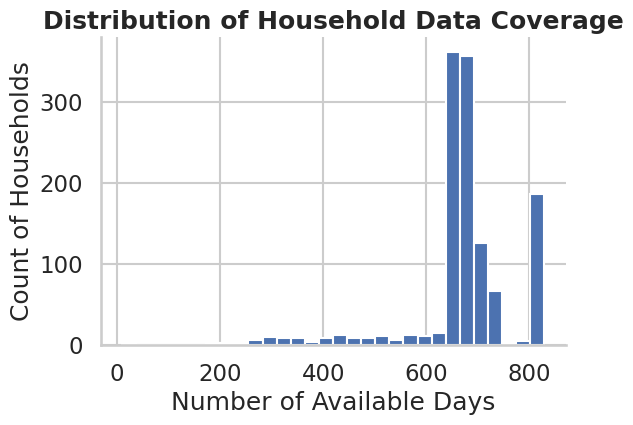

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(coverage["n_days"], bins=30)
plt.title("Distribution of Household Data Coverage")
plt.xlabel("Number of Available Days")
plt.ylabel("Count of Households")
plt.show()

### **Load Weather Data**

**Daily temperature variables are included because electricity demand is influenced by weather conditions.**

In [ ]:
def load_ecad(path: str, value_col: str, q_col: str) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=20)
    df.columns = ["SOUID", "DATE", value_col, q_col]
    df["date"] = pd.to_datetime(df["DATE"], format="%Y%m%d", errors="coerce")
    return df[["date", value_col]]

In [ ]:
tg = load_ecad(tg_path, "TG", "Q_TG")
tx = load_ecad(tx_path, "TX", "Q_TX")
tn = load_ecad(tn_path, "TN", "Q_TN")

In [ ]:
tg["temp_mean"] = tg["TG"] / 10
tx["temp_max"] = tx["TX"] / 10
tn["temp_min"] = tn["TN"] / 10

In [ ]:
weather = (
    tg[["date", "temp_mean"]]
    .merge(tx[["date", "temp_max"]], on="date", how="inner")
    .merge(tn[["date", "temp_min"]], on="date", how="inner")
)

print("Weather shape:", weather.shape)
weather.head()

Weather shape: (17166, 4)


,date,temp_mean,temp_max,temp_min
0,1979-01-02,-2.600,1.600,-7.500
1,1979-01-03,-2.800,1.300,-7.200
2,1979-01-04,-2.600,-0.300,-6.500
3,1979-01-05,-0.800,5.600,-1.400
4,1979-01-06,-0.500,8.300,-6.600


**Observation**:Daily mean, maximum, and minimum temperature variables were prepared successfully and are ready to be merged with energy data.

### **Load Carbon Intensity Data**

**Daily carbon intensity is used to estimate the environmental impact of electricity use.**

In [ ]:
carbon_raw = pd.read_csv(carbon_path)
carbon_raw["DATETIME"] = pd.to_datetime(carbon_raw["DATETIME"], errors="coerce")
carbon_raw["date"] = carbon_raw["DATETIME"].dt.normalize()

In [ ]:
carbon_daily = (
    carbon_raw.groupby("date", as_index=False)["CARBON_INTENSITY"]
    .mean()
    .rename(columns={"CARBON_INTENSITY": "carbon_intensity"})
)

print("Carbon daily shape:", carbon_daily.shape)
carbon_daily.head()

Carbon daily shape: (6263, 2)


,date,carbon_intensity
0,2009-01-01,541.688
1,2009-01-02,571.938
2,2009-01-03,566.750
3,2009-01-04,565.938
4,2009-01-05,586.042


**Observation**:The carbon intensity data was aggregated to daily level so it can be aligned with daily electricity consumption.

### **Merge Energy, Weather, and Carbon Data**


**All datasets are merged by date to build the final analytical dataset.**

In [ ]:
start_date = energy_daily["date"].min()
end_date = energy_daily["date"].max()

weather_f = weather[(weather["date"] >= start_date) & (weather["date"] <= end_date)].copy()
carbon_f = carbon_daily[(carbon_daily["date"] >= start_date) & (carbon_daily["date"] <= end_date)].copy()

In [ ]:
merged = energy_daily.merge(weather_f, on="date", how="left")
merged2 = merged.merge(carbon_f, on="date", how="left")

print("Merged shape:", merged2.shape)
merged2.head()

Merged shape: (836365, 8)


,LCLid,date,daily_kWh,daily_kWh_log,temp_mean,temp_max,temp_min,carbon_intensity
0,MAC000002,2012-10-12,7.098,2.092,12.300,13.500,9.700,527.625
1,MAC000002,2012-10-13,11.087,2.492,9.600,12.900,5.600,556.479
2,MAC000002,2012-10-14,13.223,2.655,7.400,14.200,1.900,547.667
3,MAC000002,2012-10-15,10.257,2.421,8.600,15.900,2.900,549.333
4,MAC000002,2012-10-16,9.769,2.377,12.100,17.500,8.300,540.667


In [ ]:
print("Missing values:")
print(merged2[["temp_mean", "temp_max", "temp_min", "carbon_intensity"]].isna().sum())

Missing values:
temp_mean           0
temp_max            0
temp_min            0
carbon_intensity    0
dtype: int64


**Observation**:The three data sources were merged successfully. The resulting dataset now contains electricity use, temperature information, and carbon intensity for each household-day.

### **Exploratory Data Analysis**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk", font_scale=0.9)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "medium"

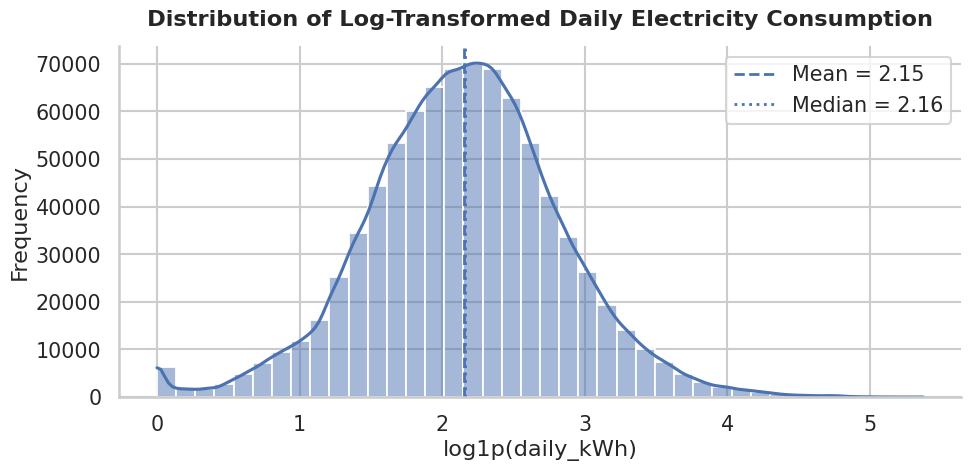

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=merged2,
    x="daily_kWh_log",
    bins=40,
    kde=True,
    ax=ax
)

mean_val = merged2["daily_kWh_log"].mean()
median_val = merged2["daily_kWh_log"].median()

ax.axvline(mean_val, linestyle="--", linewidth=2, label=f"Mean = {mean_val:.2f}")
ax.axvline(median_val, linestyle=":", linewidth=2, label=f"Median = {median_val:.2f}")

ax.set_title("Distribution of Log-Transformed Daily Electricity Consumption", pad=15)
ax.set_xlabel("log1p(daily_kWh)")
ax.set_ylabel("Frequency")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

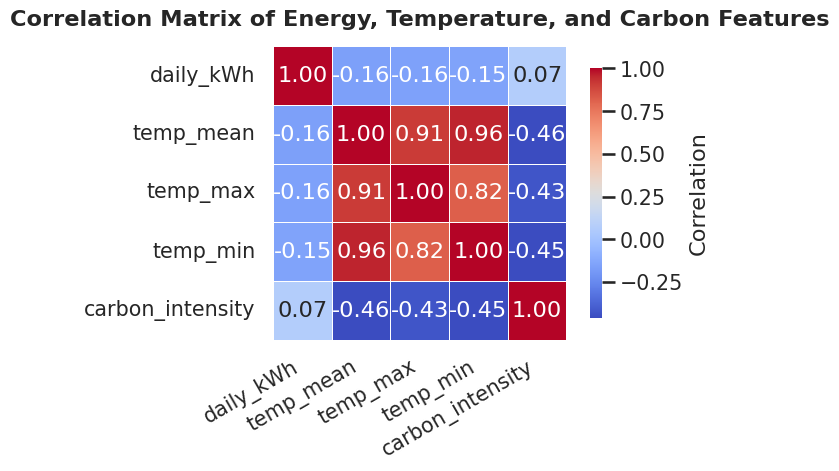

In [ ]:
corr = merged2[["daily_kWh", "temp_mean", "temp_max", "temp_min", "carbon_intensity"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.7,
    square=True,
    cbar_kws={"shrink": 0.85, "label": "Correlation"}
)
plt.title("Correlation Matrix of Energy, Temperature, and Carbon Features", pad=15)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

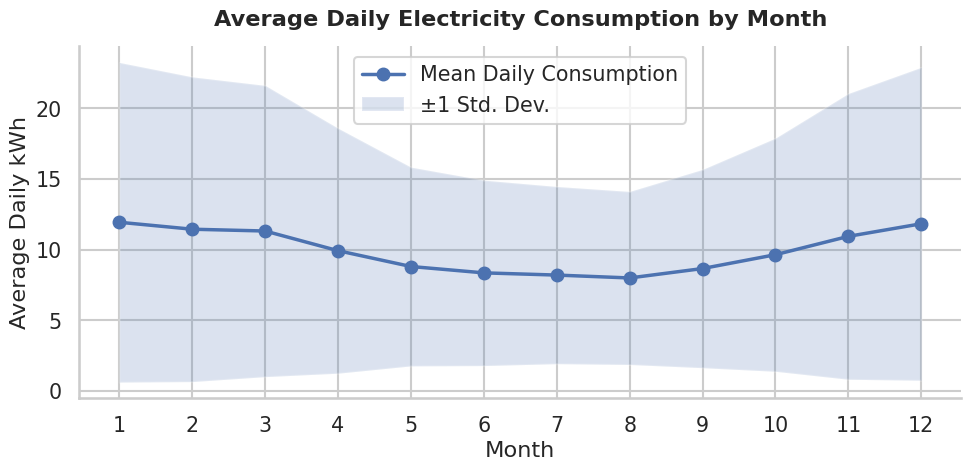

In [ ]:
monthly_stats = merged2.groupby(merged2["date"].dt.month)["daily_kWh"].agg(["mean", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(monthly_stats["date"], monthly_stats["mean"], linewidth=2.5, marker="o", label="Mean Daily Consumption")
ax.fill_between(
    monthly_stats["date"],
    monthly_stats["mean"] - monthly_stats["std"],
    monthly_stats["mean"] + monthly_stats["std"],
    alpha=0.2,
    label="±1 Std. Dev."
)

ax.set_title("Average Daily Electricity Consumption by Month", pad=15)
ax.set_xlabel("Month")
ax.set_ylabel("Average Daily kWh")
ax.set_xticks(range(1, 13))
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

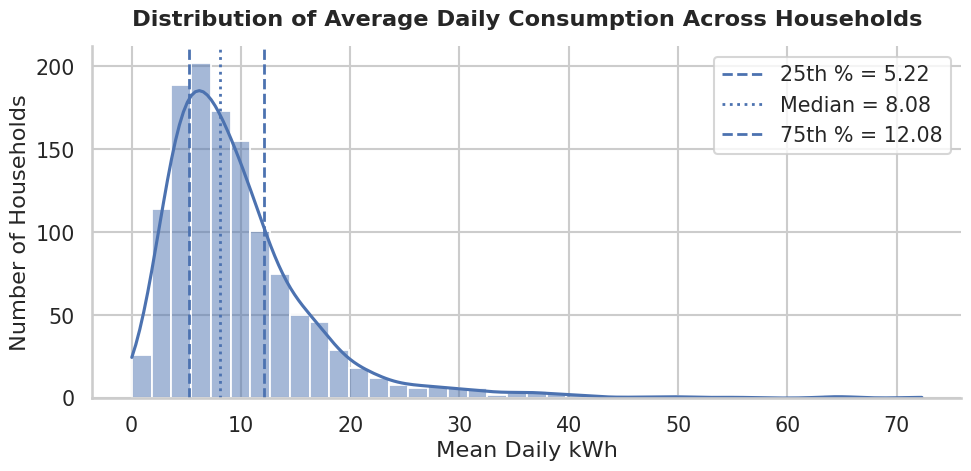

In [ ]:
household_stats = merged2.groupby("LCLid")["daily_kWh"].agg(["mean", "median", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(household_stats["mean"], bins=40, kde=True, ax=ax)

p25 = household_stats["mean"].quantile(0.25)
p50 = household_stats["mean"].quantile(0.50)
p75 = household_stats["mean"].quantile(0.75)

ax.axvline(p25, linestyle="--", linewidth=2, label=f"25th % = {p25:.2f}")
ax.axvline(p50, linestyle=":", linewidth=2, label=f"Median = {p50:.2f}")
ax.axvline(p75, linestyle="--", linewidth=2, label=f"75th % = {p75:.2f}")

ax.set_title("Distribution of Average Daily Consumption Across Households", pad=15)
ax.set_xlabel("Mean Daily kWh")
ax.set_ylabel("Number of Households")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

Outlier rows: 49005
Outlier percentage: 5.86 %


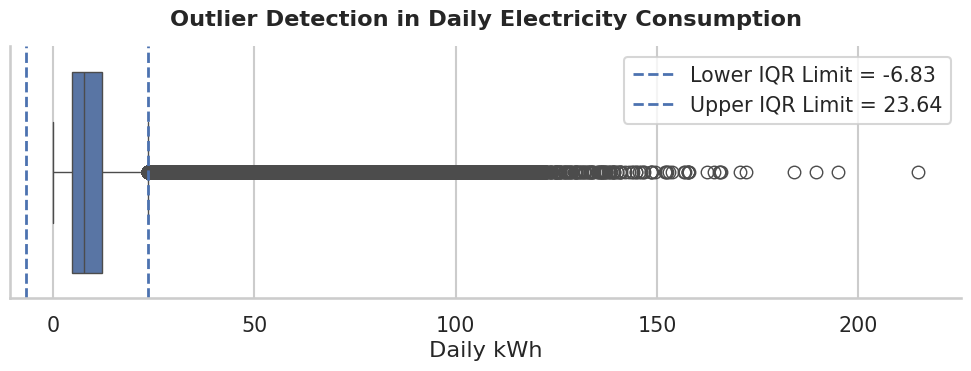

In [ ]:
Q1 = merged2["daily_kWh"].quantile(0.25)
Q3 = merged2["daily_kWh"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = merged2[(merged2["daily_kWh"] < lower) | (merged2["daily_kWh"] > upper)]

print("Outlier rows:", len(outliers))
print("Outlier percentage:", round(100 * len(outliers) / len(merged2), 2), "%")

fig, ax = plt.subplots(figsize=(10, 4))

sns.boxplot(x=merged2["daily_kWh"], ax=ax)
ax.axvline(lower, linestyle="--", linewidth=2, label=f"Lower IQR Limit = {lower:.2f}")
ax.axvline(upper, linestyle="--", linewidth=2, label=f"Upper IQR Limit = {upper:.2f}")

ax.set_title("Outlier Detection in Daily Electricity Consumption", pad=15)
ax.set_xlabel("Daily kWh")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

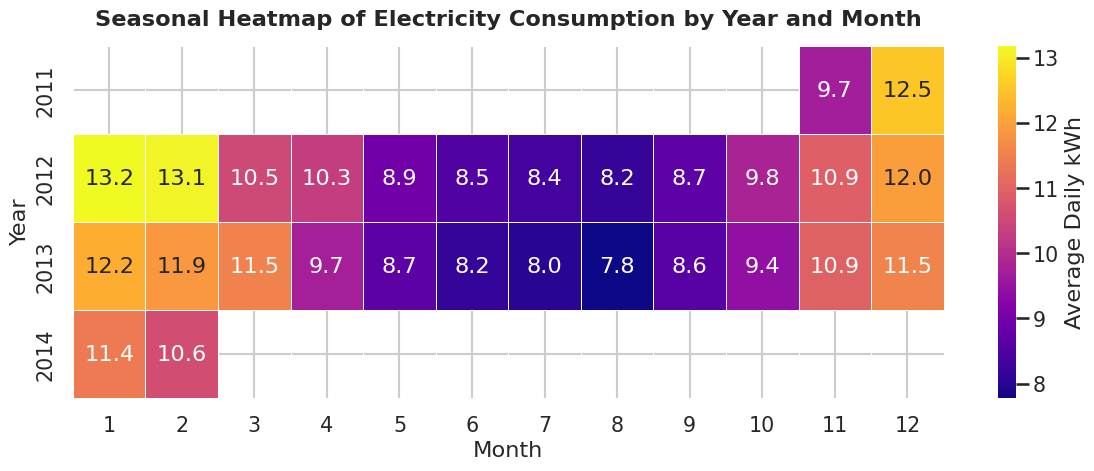

In [ ]:
season_df = merged2.copy()
season_df["year"] = season_df["date"].dt.year
season_df["month"] = season_df["date"].dt.month

season_pivot = season_df.groupby(["year", "month"])["daily_kWh"].mean().unstack()

plt.figure(figsize=(12, 5))
sns.heatmap(
    season_pivot,
    cmap="plasma",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Average Daily kWh"}
)
plt.title("Seasonal Heatmap of Electricity Consumption by Year and Month", pad=15)
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

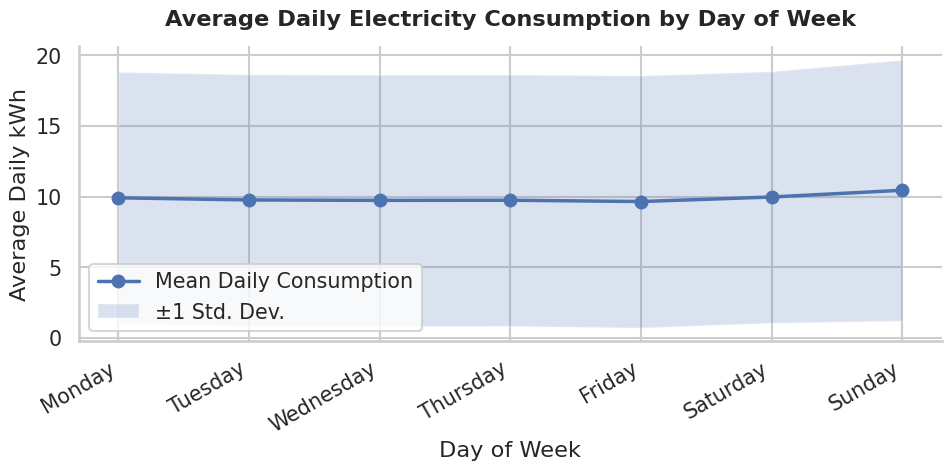

In [ ]:
weekly_stats = (
    merged2.assign(day_name=merged2["date"].dt.day_name())
    .groupby("day_name")["daily_kWh"]
    .agg(["mean", "std"])
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(weekly_stats))

ax.plot(x, weekly_stats["mean"], marker="o", linewidth=2.5, label="Mean Daily Consumption")
ax.fill_between(
    x,
    weekly_stats["mean"] - weekly_stats["std"],
    weekly_stats["mean"] + weekly_stats["std"],
    alpha=0.2,
    label="±1 Std. Dev."
)

ax.set_xticks(x)
ax.set_xticklabels(weekly_stats["day_name"], rotation=30, ha="right")
ax.set_title("Average Daily Electricity Consumption by Day of Week", pad=15)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Daily kWh")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

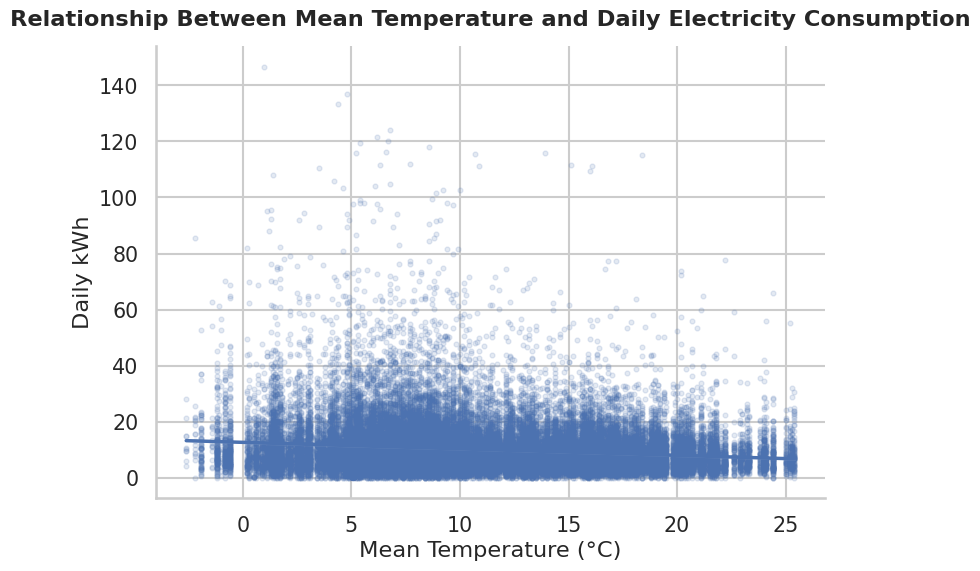

In [ ]:
sample_df = merged2.sample(min(50000, len(merged2)), random_state=42)

plt.figure(figsize=(8, 6))
sns.regplot(
    data=sample_df,
    x="temp_mean",
    y="daily_kWh",
    scatter_kws={"alpha": 0.15, "s": 12},
    line_kws={"linewidth": 2.5}
)
plt.title("Relationship Between Mean Temperature and Daily Electricity Consumption", pad=15)
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Daily kWh")
plt.tight_layout()
plt.show()

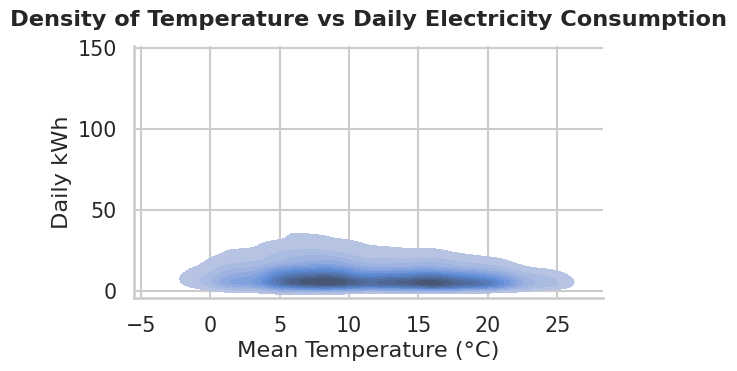

In [ ]:
plt.figure(figsize=(6, 4))
sns.kdeplot(
    data=sample_df,
    x="temp_mean",
    y="daily_kWh",
    fill=True,
    thresh=0.05,
    levels=15
)
plt.title("Density of Temperature vs Daily Electricity Consumption", pad=15)
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Daily kWh")
plt.tight_layout()
plt.show()

**This section examines the distribution, seasonality, weather relationship, and between-household variation in electricity demand.**

**1 Distribution of Daily Consumption**

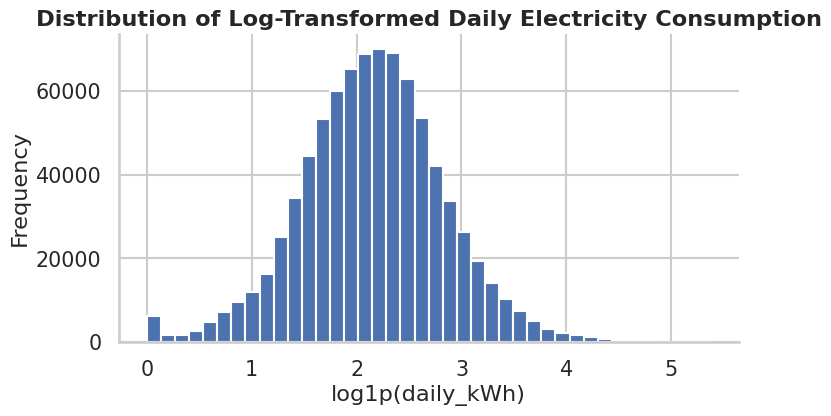

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(merged2["daily_kWh_log"], bins=40)
plt.title("Distribution of Log-Transformed Daily Electricity Consumption")
plt.xlabel("log1p(daily_kWh)")
plt.ylabel("Frequency")
plt.show()

**Observation**:The log transformation reduces skewness in the daily consumption distribution, making it easier to analyse and model.

**2.Correlation Analysis**

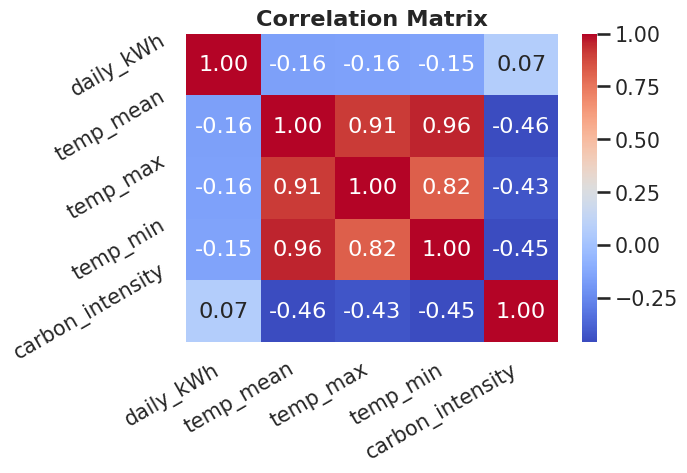

In [ ]:
corr = merged2[["daily_kWh", "temp_mean", "temp_max", "temp_min", "carbon_intensity"]].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=30)

plt.show()

**3.Monthly Seasonality**

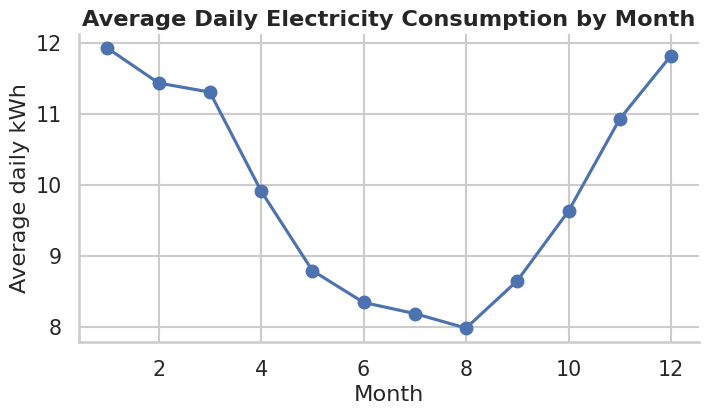

In [ ]:
monthly_profile = merged2.groupby(merged2["date"].dt.month)["daily_kWh"].mean()

plt.figure(figsize=(8,4))
monthly_profile.plot(marker="o")
plt.title("Average Daily Electricity Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average daily kWh")
plt.show()

**Observation**: Seasonal patterns are visible across months, supporting the use of STL decomposition as part of the drift detection framework.

**4 Day-of-Week Behaviour**

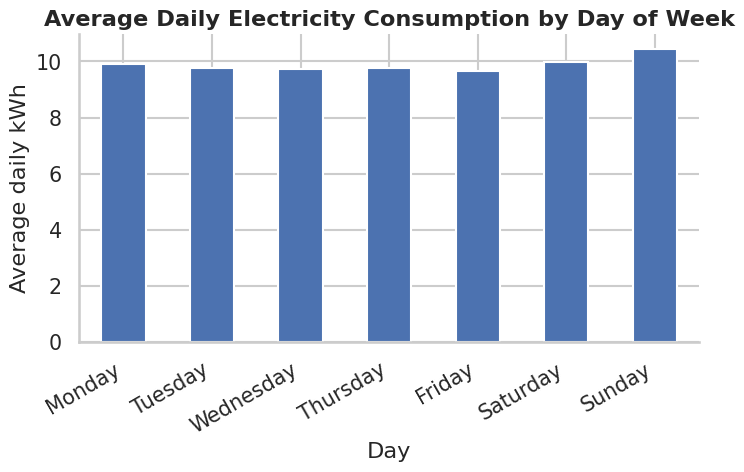

In [ ]:
weekly_profile = merged2.groupby(merged2["date"].dt.day_name())["daily_kWh"].mean()
weekly_profile = weekly_profile.reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])

plt.figure(figsize=(8,4))
weekly_profile.plot(kind="bar")
plt.title("Average Daily Electricity Consumption by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average daily kWh")
plt.xticks(rotation=30, ha='right')
plt.show()

**5 Weather vs Energy**

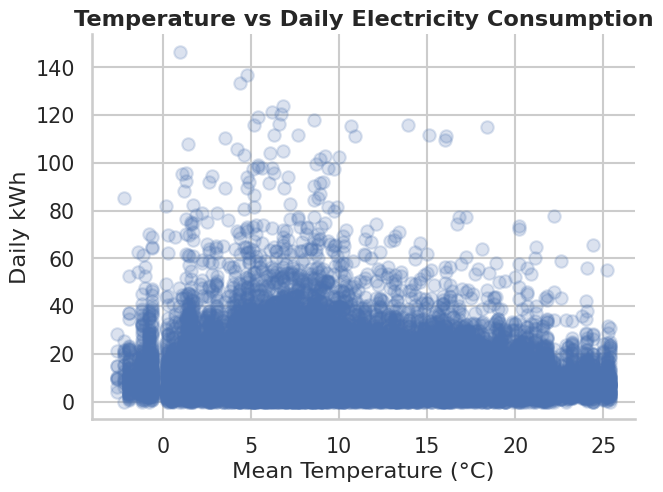

In [ ]:
sample_df = merged2.sample(min(50000, len(merged2)), random_state=42)

plt.figure(figsize=(7,5))
plt.scatter(sample_df["temp_mean"], sample_df["daily_kWh"], alpha=0.2)
plt.title("Temperature vs Daily Electricity Consumption")
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Daily kWh")
plt.show()

**Observation**: The relationship between temperature and energy demand is not identical across households, which supports household-level modelling rather than a single pooled approach.

**6 Household Heterogeneity**

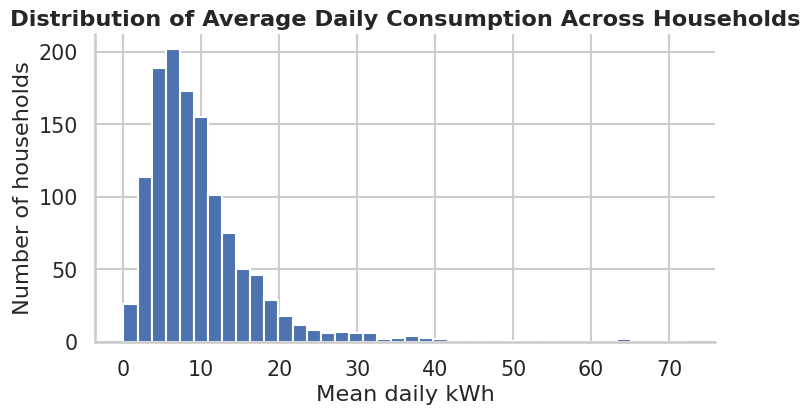

In [ ]:
household_stats = merged2.groupby("LCLid")["daily_kWh"].agg(["mean", "median", "std"]).reset_index()

plt.figure(figsize=(8,4))
plt.hist(household_stats["mean"], bins=40)
plt.title("Distribution of Average Daily Consumption Across Households")
plt.xlabel("Mean daily kWh")
plt.ylabel("Number of households")
plt.show()

**Observation**: There is substantial heterogeneity in average household electricity consumption. This justifies comparing results across multiple homes.

**7 Missingness Check**

In [ ]:
missing_summary = merged2.isna().mean().sort_values(ascending=False) * 100
missing_summary

,0
LCLid,0.000
date,0.000
daily_kWh,0.000
daily_kWh_log,0.000
temp_mean,0.000
temp_max,0.000
temp_min,0.000
carbon_intensity,0.000


**Observation**: The missing value summary identifies which variables require careful treatment during feature engineering and modelling.

**8 Outlier Detection Using IQR**

In [ ]:
Q1 = merged2["daily_kWh"].quantile(0.25)
Q3 = merged2["daily_kWh"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = merged2[(merged2["daily_kWh"] < lower) | (merged2["daily_kWh"] > upper)]
print("Outlier rows:", len(outliers))
print("Outlier percentage:", round(100 * len(outliers) / len(merged2), 2), "%")

Outlier rows: 49005
Outlier percentage: 5.86 %


**Observation**: Outliers are present in the daily electricity data. These may reflect unusual events, high-usage days, or possible data irregularities.

### **14. Feature Engineering**

**Calendar, cyclical, lag, rolling, and heating-related features are created to support forecasting models.**

In [ ]:

df = merged2.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["LCLid", "date"]).reset_index(drop=True)

# Calendar features
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["day_of_month"] = df["date"].dt.day
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# Cyclical encoding
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Heating degree days
df["HDD_18"] = np.maximum(0, 18 - df["temp_mean"])

# Lag features per household
lag_days = [1, 2, 3, 7, 14, 30]
for L in lag_days:
    df[f"lag_{L}"] = df.groupby("LCLid")["daily_kWh"].shift(L)

# Rolling features without leakage
roll_windows = [7, 14, 30]
g = df.groupby("LCLid")["daily_kWh"]
for w in roll_windows:
    shifted = g.shift(1)
    df[f"roll_mean_{w}"] = shifted.rolling(w, min_periods=max(3, w//3)).mean()
    df[f"roll_std_{w}"] = shifted.rolling(w, min_periods=max(3, w//3)).std()
    df[f"roll_min_{w}"] = shifted.rolling(w, min_periods=max(3, w//3)).min()
    df[f"roll_max_{w}"] = shifted.rolling(w, min_periods=max(3, w//3)).max()

needed = [f"lag_{L}" for L in lag_days] + [f"roll_mean_{w}" for w in roll_windows]
df_model = df.dropna(subset=needed + ["temp_mean", "carbon_intensity"]).copy()

print("Model-ready shape:", df_model.shape)
df_model.head()

Model-ready shape: (799055, 36)


,LCLid,date,daily_kWh,daily_kWh_log,temp_mean,temp_max,temp_min,carbon_intensity,day_of_week,month,year,day_of_month,is_weekend,dow_sin,dow_cos,month_sin,month_cos,HDD_18,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,roll_mean_7,roll_std_7,roll_min_7,roll_max_7,roll_mean_14,roll_std_14,roll_min_14,roll_max_14,roll_mean_30,roll_std_30,roll_min_30,roll_max_30
30,MAC000002,2012-11-11,10.699,2.460,6.000,12.700,1.300,541.438,6,11,2012,11,1,-0.782,0.623,-0.500,0.866,12.000,13.245,16.722,0.186,14.507,19.629,7.098,12.079,5.487,0.186,16.722,13.561,4.431,0.186,19.629,13.447,4.395,0.186,24.490
31,MAC000002,2012-11-12,12.321,2.589,8.000,15.500,3.200,535.438,0,11,2012,12,0,0.000,1.000,-0.500,0.866,10.000,10.699,13.245,16.722,15.095,12.779,11.087,11.535,5.394,0.186,16.722,12.923,4.122,0.186,17.822,13.567,4.263,0.186,24.490
32,MAC000002,2012-11-13,10.264,2.422,11.400,14.200,7.300,525.167,1,11,2012,13,0,0.782,0.623,-0.500,0.866,6.600,12.321,10.699,13.245,11.663,13.961,13.223,11.139,5.187,0.186,16.722,12.891,4.125,0.186,17.822,13.608,4.244,0.186,24.490
33,MAC000002,2012-11-14,10.820,2.470,12.000,10.100,9.700,563.188,2,11,2012,14,0,0.975,-0.223,-0.500,0.866,6.000,10.264,12.321,10.699,13.137,17.822,10.257,10.939,5.190,0.186,16.722,12.626,4.169,0.186,17.822,13.510,4.288,0.186,24.490
34,MAC000002,2012-11-15,9.808,2.380,7.100,12.600,4.000,581.688,3,11,2012,15,0,0.434,-0.901,-0.500,0.866,10.900,10.820,10.264,12.321,0.186,12.209,9.769,10.608,5.100,0.186,16.722,12.126,3.910,0.186,16.722,13.528,4.274,0.186,24.490


**Observation**: The engineered features capture short-term memory, longer-term behaviour, seasonality, and weather effects.

## **Train, validation, and test split**

In [ ]:
TEST_DAYS = 60
VAL_DAYS = 30

merged2 = merged2.sort_values(["LCLid", "date"]).copy()
merged2["date"] = pd.to_datetime(merged2["date"])

max_date = merged2["date"].max()
test_start = max_date - pd.Timedelta(days=TEST_DAYS - 1)
val_start = test_start - pd.Timedelta(days=VAL_DAYS)

train_df = merged2[merged2["date"] < val_start].copy()
val_df = merged2[(merged2["date"] >= val_start) & (merged2["date"] < test_start)].copy()
test_df = merged2[merged2["date"] >= test_start].copy()


print("Validation starts:", val_start)
print("Test starts:", test_start)
print("Max date:", max_date)
print("Train date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Validation date range:", val_df["date"].min(), "to", val_df["date"].max())
print("Test date range:", test_df["date"].min(), "to", test_df["date"].max())

Validation starts: 2013-12-01 00:00:00
Test starts: 2013-12-31 00:00:00
Max date: 2014-02-28 00:00:00
Train date range: 2011-11-23 00:00:00 to 2013-11-30 00:00:00
Validation date range: 2013-12-01 00:00:00 to 2013-12-30 00:00:00
Test date range: 2013-12-31 00:00:00 to 2014-02-28 00:00:00


**Observation**: The final 60 days are reserved for testing. The 30 days before the test window are used as a validation period for model tuning and monitoring.

## **Select eligible households**

Only households with sufficient historical data are retained for multi-household modelling.


In [ ]:
coverage2 = merged2.groupby("LCLid").agg(
    n_days=("date", "count"),
    start=("date", "min"),
    end=("date", "max")
).reset_index()

eligible_households = coverage2.loc[coverage2["n_days"] >= 150, "LCLid"].tolist()

print("Eligible households:", len(eligible_households))
print("Example households:", eligible_households[:10])

Eligible households: 1243
Example households: ['MAC000002', 'MAC000003', 'MAC000004', 'MAC000006', 'MAC000007', 'MAC000008', 'MAC000009', 'MAC000010', 'MAC000011', 'MAC000012']


In [ ]:
N_HOUSEHOLDS =30
selected_households = eligible_households[:N_HOUSEHOLDS]

print("Selected households:", selected_households)

Selected households: ['MAC000002', 'MAC000003', 'MAC000004', 'MAC000006', 'MAC000007', 'MAC000008', 'MAC000009', 'MAC000010', 'MAC000011', 'MAC000012', 'MAC000013', 'MAC000016', 'MAC000018', 'MAC000019', 'MAC000020', 'MAC000021', 'MAC000022', 'MAC000023', 'MAC000024', 'MAC000025', 'MAC000026', 'MAC000027', 'MAC000028', 'MAC000029', 'MAC000030', 'MAC000032', 'MAC000033', 'MAC000034', 'MAC000035', 'MAC000036']


**Observation**: A filtered set of households was selected to ensure each model has enough historical information for stable training and evaluation.

## **Drift Detection Function**

In [ ]:
def cusum_drift(residuals):
    """
    Apply two-sided CUSUM to residuals.

    Returns
    -------
    cusum_pos : positive cumulative sum
    cusum_neg : negative cumulative sum
    alerts    : boolean alert vector
    k         : allowance parameter
    h         : threshold parameter
    """
    residuals = np.asarray(residuals, dtype=float)
    residuals = np.nan_to_num(residuals, nan=0.0)

    sigma = np.std(residuals)
    if sigma == 0 or np.isnan(sigma):
        n = len(residuals)
        return np.zeros(n), np.zeros(n), np.zeros(n, dtype=bool), 0.0, 0.0

    k = 0.5 * sigma
    h = 5.0 * sigma

    cusum_pos = [0.0]
    cusum_neg = [0.0]

    for i in range(1, len(residuals)):
        cp = max(0.0, cusum_pos[-1] + residuals[i] - k)
        cn = min(0.0, cusum_neg[-1] + residuals[i] + k)
        cusum_pos.append(cp)
        cusum_neg.append(cn)

    cusum_pos = np.array(cusum_pos)
    cusum_neg = np.array(cusum_neg)
    alerts = (cusum_pos > h) | (cusum_neg < -h)

    return cusum_pos, cusum_neg, alerts, k, h

In [ ]:

def ewma_drift(residuals, alpha=0.3, threshold=2.0):
    """
    Apply EWMA monitoring to residuals.

    Returns
    -------
    ewma   : exponentially weighted moving average
    alerts : boolean alerts
    upper  : upper control limit
    lower  : lower control limit
    """
    residuals = np.asarray(residuals, dtype=float)
    residuals = np.nan_to_num(residuals, nan=0.0)

    if len(residuals) == 0:
        return np.array([]), np.array([], dtype=bool), np.nan, np.nan

    ewma = []
    s = residuals[0]

    for r in residuals:
        s = alpha * r + (1 - alpha) * s
        ewma.append(s)

    ewma = np.array(ewma)
    mean_ewma = np.mean(ewma)
    std_ewma = np.std(ewma)

    if std_ewma == 0 or np.isnan(std_ewma):
        alerts = np.zeros(len(ewma), dtype=bool)
        upper = mean_ewma
        lower = mean_ewma
    else:
        upper = mean_ewma + threshold * std_ewma
        lower = mean_ewma - threshold * std_ewma
        alerts = (ewma > upper) | (ewma < lower)

    return ewma, alerts, upper, lower

## **STL baseline**

In [ ]:
def stl_baseline(df_home, period=7, min_days=30):
    x = df_home[["date", "daily_kWh"]].dropna().sort_values("date").copy()
    x = x.set_index("date").asfreq("D")
    x["daily_kWh"] = x["daily_kWh"].interpolate(limit=7)

    if x["daily_kWh"].dropna().shape[0] < min_days:
        return None

    stl = STL(x["daily_kWh"], period=period, robust=True)
    res = stl.fit()

    x["trend"] = res.trend
    x["seasonal"] = res.seasonal
    x["expected_kWh"] = res.trend + res.seasonal
    x["residual"] = x["daily_kWh"] - x["expected_kWh"]

    return x.reset_index()

In [ ]:
def evaluate_early_detection(home_test, alert_col="cusum_alert", residual_col="residual_test", consecutive_days=3):
    """
    Evaluate how early alerts happen before a sustained inefficient event.
    """
    temp = home_test.copy()

    if temp.empty:
        return {
            "event_date": pd.NaT,
            "first_alert": pd.NaT,
            "lead_time_days": np.nan,
            "false_alarm_rate": np.nan,
            "stability_score": np.nan,
            "event_threshold": np.nan,
        }

    threshold = temp[residual_col].mean() + temp[residual_col].std()
    temp["event_flag"] = (temp[residual_col] > threshold).astype(int)
    temp["event_run"] = temp["event_flag"].rolling(consecutive_days).sum()

    event_date = temp.loc[temp["event_run"] >= consecutive_days, "date"].min()
    first_alert = temp.loc[temp[alert_col], "date"].min()

    lead_time = (event_date - first_alert).days if pd.notna(event_date) and pd.notna(first_alert) else np.nan

    false_alarms = (
        temp[(temp[alert_col] == True) & (temp["date"] < event_date)]
        if pd.notna(event_date)
        else pd.DataFrame()
    )
    false_alarm_rate = len(false_alarms) / len(temp) if len(temp) > 0 else np.nan
    stability = temp[alert_col].rolling(consecutive_days).sum().max()

    return {
        "event_date": event_date,
        "first_alert": first_alert,
        "lead_time_days": lead_time,
        "false_alarm_rate": false_alarm_rate,
        "stability_score": stability,
        "event_threshold": threshold,
    }


## **STL + CUSUM + EWMA for one household**

In [ ]:
def run_stl_for_household(df_home, test_start, period=7):
    df_home = df_home.sort_values("date").copy()

    train_home = df_home[df_home["date"] < test_start].copy()
    test_home = df_home[df_home["date"] >= test_start].copy()

    if len(train_home) < 60 or len(test_home) == 0:
        return None, None

    train_stl = stl_baseline(train_home, period=period)
    if train_stl is None:
        return None, None

    expected_vals = []
    residuals = []

    values = df_home["daily_kWh"].values
    dates = df_home["date"].values

    for i in range(len(df_home)):
        if dates[i] < np.datetime64(test_start):
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        past_df = df_home.iloc[:i]
        if len(past_df) < 30:
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        stl_df = stl_baseline(past_df, period=period)
        if stl_df is None:
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        expected_today = stl_df["expected_kWh"].iloc[-7:].mean()
        expected_vals.append(expected_today)
        residuals.append(values[i] - expected_today)

    df_home["expected_test"] = expected_vals
    df_home["residual_test"] = residuals

    home_test = df_home[df_home["date"] >= test_start].copy()
    r = home_test["residual_test"].fillna(0).values

    cusum_pos, cusum_neg, cusum_alert, k, h = cusum_drift(r)
    ewma_vals, ewma_alert, ewma_upper, ewma_lower = ewma_drift(r)

    home_test["cusum_pos"] = cusum_pos
    home_test["cusum_neg"] = cusum_neg
    home_test["cusum_alert"] = cusum_alert
    home_test["cusum_k"] = k
    home_test["cusum_h"] = h

    home_test["ewma"] = ewma_vals
    home_test["ewma_alert"] = ewma_alert
    home_test["ewma_upper"] = ewma_upper
    home_test["ewma_lower"] = ewma_lower

    summary = pd.DataFrame({
        "LCLid": [df_home["LCLid"].iloc[0]],
        "cusum_first_alert": [home_test.loc[home_test["cusum_alert"], "date"].min()],
        "cusum_num_alerts": [int(home_test["cusum_alert"].sum())],
        "cusum_max_drift": [float(np.max(np.abs(home_test["cusum_neg"]))) if len(home_test) else np.nan],
        "ewma_first_alert": [home_test.loc[home_test["ewma_alert"], "date"].min()],
        "ewma_num_alerts": [int(home_test["ewma_alert"].sum())],
        "ewma_max_drift": [float(np.max(np.abs(home_test["ewma"]))) if len(home_test) else np.nan]
    })

    return summary, home_test

## **Early detection evaluation**

In [ ]:
def evaluate_early_detection(home_test, alert_col="cusum_alert", residual_col="residual_test", consecutive_days=3):
    temp = home_test.copy()

    if temp.empty:
        return {
            "event_date": pd.NaT,
            "first_alert": pd.NaT,
            "lead_time_days": np.nan,
            "false_alarm_rate": np.nan,
            "stability_score": np.nan
        }

    threshold = temp[residual_col].mean() + temp[residual_col].std()
    temp["event_flag"] = (temp[residual_col] > threshold).astype(int)
    temp["event_run"] = temp["event_flag"].rolling(consecutive_days).sum()

    event_date = temp.loc[temp["event_run"] >= consecutive_days, "date"].min()
    first_alert = temp.loc[temp[alert_col], "date"].min()

    lead_time = (event_date - first_alert).days if pd.notna(event_date) and pd.notna(first_alert) else np.nan

    false_alarms = temp[(temp[alert_col] == True) & (temp["date"] < event_date)] if pd.notna(event_date) else pd.DataFrame()
    false_alarm_rate = len(false_alarms) / len(temp) if len(temp) > 0 else np.nan
    stability = temp[alert_col].rolling(consecutive_days).sum().max()

    return {
        "event_date": event_date,
        "first_alert": first_alert,
        "lead_time_days": lead_time,
        "false_alarm_rate": false_alarm_rate,
        "stability_score": stability
    }

## **TCN model for one household**

In [ ]:
def run_tcn_for_household(df_home, house_id, val_start, test_start, lookback=30, epochs=15):
    df_home = df_home.sort_values("date")[["date", "daily_kWh"]].dropna().copy()

    if len(df_home) < lookback + 100:
        return None, None, None

    scaler = MinMaxScaler()
    df_home["scaled"] = scaler.fit_transform(df_home[["daily_kWh"]])

    X, y, dates = [], [], []
    series = df_home["scaled"].values
    date_vals = df_home["date"].values

    for i in range(lookback, len(series)):
        X.append(series[i-lookback:i])
        y.append(series[i])
        dates.append(date_vals[i])

    X = np.array(X)
    y = np.array(y)
    dates = pd.to_datetime(np.array(dates))

    train_mask = dates < val_start
    val_mask = (dates >= val_start) & (dates < test_start)
    test_mask = dates >= test_start

    if train_mask.sum() < 50 or test_mask.sum() == 0:
        return None, None, None

    X_train = X[train_mask][..., np.newaxis]
    y_train = y[train_mask]
    X_test = X[test_mask][..., np.newaxis]
    y_test = y[test_mask]
    test_dates = dates[test_mask]

    model = Sequential([
        TCN(32),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")

    if val_mask.sum() > 0:
        X_val = X[val_mask][..., np.newaxis]
        y_val = y[val_mask]
        model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=16, verbose=0)
    else:
        model.fit(X_train, y_train, epochs=epochs, batch_size=16, verbose=0)

    pred_scaled = model.predict(X_test, verbose=0).flatten()
    pred = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    y_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    errors = y_actual - pred
    cusum_pos, cusum_neg, alerts, k, h = cusum_drift(errors)

    mae = mean_absolute_error(y_actual, pred)
    rmse = np.sqrt(mean_squared_error(y_actual, pred))

    summary = pd.DataFrame({
        "LCLid": [house_id],
        "tcn_first_alert": [test_dates[np.where(alerts)[0][0]] if alerts.any() else pd.NaT],
        "tcn_num_alerts": [int(alerts.sum())],
        "tcn_max_drift": [float(np.max(cusum_pos)) if len(cusum_pos) else np.nan],
        "tcn_mae": [mae],
        "tcn_rmse": [rmse]
    })

    pred_df = pd.DataFrame({
        "LCLid": house_id,
        "date": test_dates,
        "actual": y_actual,
        "predicted": pred,
        "error": errors,
        "tcn_alert": alerts
    })

    return summary, pred_df, model

## **XGBoost model for one household**

In [ ]:
def run_xgb_for_household(df_model, house_id, val_start, test_start):
    df_home = df_model[df_model["LCLid"] == house_id].copy()

    train_df = df_home[df_home["date"] < val_start].copy()
    test_df = df_home[df_home["date"] >= test_start].copy()

    if len(train_df) < 100 or len(test_df) == 0:
        return None, None, None

    feature_cols = [c for c in df_home.columns if c not in ["LCLid", "date", "daily_kWh", "daily_kWh_log"]]
    if len(feature_cols) == 0:
        return None, None, None

    X_train = train_df[feature_cols]
    y_train = train_df["daily_kWh"]
    X_test = test_df[feature_cols]
    y_test = test_df["daily_kWh"]

    model = XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    errors = y_test.values - pred

    cusum_pos, cusum_neg, alerts, k, h = cusum_drift(errors)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    summary = pd.DataFrame({
        "LCLid": [house_id],
        "xgb_first_alert": [test_df["date"].iloc[np.where(alerts)[0][0]] if alerts.any() else pd.NaT],
        "xgb_num_alerts": [int(alerts.sum())],
        "xgb_max_drift": [float(np.max(cusum_pos)) if len(cusum_pos) else np.nan],
        "xgb_mae": [mae],
        "xgb_rmse": [rmse]
    })

    pred_df = pd.DataFrame({
        "LCLid": house_id,
        "date": test_df["date"].values,
        "actual": y_test.values,
        "predicted": pred,
        "error": errors,
        "xgb_alert": alerts
    })

    return summary, pred_df, model

## **Run all models for many households**

In [ ]:
all_stl = []
all_eval_rows = []
all_tcn = []
all_xgb = []

stl_details = {}
tcn_details = {}
xgb_details = {}

for house_id in selected_households:
    print(f"Running household: {house_id}")

    df_home = merged2[merged2["LCLid"] == house_id].copy()

    stl_summary, home_test = run_stl_for_household(df_home, test_start=test_start, period=7)
    if stl_summary is not None:
        all_stl.append(stl_summary)
        stl_details[house_id] = home_test

        eval_cusum = evaluate_early_detection(home_test, alert_col="cusum_alert", residual_col="residual_test")
        eval_ewma = evaluate_early_detection(home_test, alert_col="ewma_alert", residual_col="residual_test")

        all_eval_rows.append({"LCLid": house_id, "method": "CUSUM", **eval_cusum})
        all_eval_rows.append({"LCLid": house_id, "method": "EWMA", **eval_ewma})

    tcn_summary, tcn_pred_df, _ = run_tcn_for_household(
        df_home=df_home,
        house_id=house_id,
        val_start=val_start,
        test_start=test_start,
        lookback=30,
        epochs=15
    )
    if tcn_summary is not None:
        all_tcn.append(tcn_summary)
        tcn_details[house_id] = tcn_pred_df

    xgb_summary, xgb_pred_df, _ = run_xgb_for_household(
        df_model=df_model,
        house_id=house_id,
        val_start=val_start,
        test_start=test_start
    )
    if xgb_summary is not None:
        all_xgb.append(xgb_summary)
        xgb_details[house_id] = xgb_pred_df

stl_drift_summary = pd.concat(all_stl, ignore_index=True) if all_stl else pd.DataFrame()
early_eval = pd.DataFrame(all_eval_rows)
tcn_summary_all = pd.concat(all_tcn, ignore_index=True) if all_tcn else pd.DataFrame()
xgb_summary_all = pd.concat(all_xgb, ignore_index=True) if all_xgb else pd.DataFrame()

print("STL summary shape:", stl_drift_summary.shape)
print("Early eval shape:", early_eval.shape)
print("TCN summary shape:", tcn_summary_all.shape)
print("XGB summary shape:", xgb_summary_all.shape)


Running household: MAC000002
Running household: MAC000003
Running household: MAC000004
Running household: MAC000006
Running household: MAC000007
Running household: MAC000008
Running household: MAC000009
Running household: MAC000010
Running household: MAC000011
Running household: MAC000012
Running household: MAC000013
Running household: MAC000016
Running household: MAC000018
Running household: MAC000019
Running household: MAC000020
Running household: MAC000021
Running household: MAC000022
Running household: MAC000023
Running household: MAC000024
Running household: MAC000025
Running household: MAC000026
Running household: MAC000027
Running household: MAC000028
Running household: MAC000029
Running household: MAC000030
Running household: MAC000032
Running household: MAC000033
Running household: MAC000034
Running household: MAC000035
Running household: MAC000036
STL summary shape: (27, 7)
Early eval shape: (54, 7)
TCN summary shape: (27, 6)
XGB summary shape: (27, 6)


## **View result tables**

In [ ]:
display(stl_drift_summary)
display(early_eval)
display(tcn_summary_all)
display(xgb_summary_all)

,LCLid,cusum_first_alert,cusum_num_alerts,cusum_max_drift,ewma_first_alert,ewma_num_alerts,ewma_max_drift
0,MAC000002,2014-02-15,1,20.466,2014-01-27,3,4.599
1,MAC000003,2014-01-16,2,53.522,2014-02-22,1,13.998
2,MAC000004,2014-02-28,1,1.480,2014-02-28,1,0.483
3,MAC000006,2014-02-28,1,2.873,2013-12-31,2,1.017
4,MAC000007,NaT,0,16.108,2014-01-04,4,5.621
5,MAC000009,NaT,0,8.180,2014-02-28,1,2.739
6,MAC000010,NaT,0,24.240,2014-02-28,1,8.682
7,MAC000011,NaT,0,8.986,2013-12-31,4,3.883
8,MAC000012,NaT,0,1.059,2014-01-21,3,0.410
9,MAC000013,NaT,0,4.582,2014-02-18,3,1.502


,LCLid,method,event_date,first_alert,lead_time_days,false_alarm_rate,stability_score
0,MAC000002,CUSUM,NaT,2014-02-15,NaN,0.000,1.000
1,MAC000002,EWMA,NaT,2014-01-27,NaN,0.000,2.000
2,MAC000003,CUSUM,2014-01-13,2014-01-16,-3.000,0.000,2.000
3,MAC000003,EWMA,2014-01-13,2014-02-22,-40.000,0.000,1.000
4,MAC000004,CUSUM,NaT,2014-02-28,NaN,0.000,1.000
5,MAC000004,EWMA,NaT,2014-02-28,NaN,0.000,1.000
6,MAC000006,CUSUM,NaT,2014-02-28,NaN,0.000,1.000
7,MAC000006,EWMA,NaT,2013-12-31,NaN,0.000,1.000
8,MAC000007,CUSUM,NaT,NaT,NaN,0.000,0.000
9,MAC000007,EWMA,NaT,2014-01-04,NaN,0.000,2.000


,LCLid,tcn_first_alert,tcn_num_alerts,tcn_max_drift,tcn_mae,tcn_rmse
0,MAC000002,NaT,0,8.548,3.997,5.030
1,MAC000003,NaT,0,26.399,8.968,11.133
2,MAC000004,2014-02-28,1,0.153,0.188,0.314
3,MAC000006,2014-02-28,1,1.110,0.339,0.594
4,MAC000007,NaT,0,33.997,5.186,7.547
5,MAC000009,2014-02-28,1,2.463,1.445,2.027
6,MAC000010,NaT,0,24.690,5.839,7.758
7,MAC000011,NaT,0,10.133,2.581,3.548
8,MAC000012,2014-01-24,8,0.710,0.194,0.331
9,MAC000013,2014-01-07,23,8.447,0.965,1.294


,LCLid,xgb_first_alert,xgb_num_alerts,xgb_max_drift,xgb_mae,xgb_rmse
0,MAC000002,2014-01-31,2,23.241,3.387,4.680
1,MAC000003,NaT,0,24.551,6.355,8.908
2,MAC000004,2014-02-28,1,0.057,0.136,0.255
3,MAC000006,2014-02-28,1,0.933,0.346,0.555
4,MAC000007,NaT,0,18.270,3.033,4.681
5,MAC000009,NaT,0,3.323,1.101,1.685
6,MAC000010,2014-02-18,11,68.827,5.249,6.786
7,MAC000011,NaT,0,8.551,2.583,3.439
8,MAC000012,2014-01-23,3,1.021,0.182,0.402
9,MAC000013,2014-01-21,7,3.689,0.758,1.080


## **Final comparison table**

In [ ]:
comparison = stl_drift_summary.merge(tcn_summary_all, on="LCLid", how="outer")
comparison = comparison.merge(xgb_summary_all, on="LCLid", how="outer")

display(comparison)

,LCLid,cusum_first_alert,cusum_num_alerts,cusum_max_drift,ewma_first_alert,ewma_num_alerts,ewma_max_drift,tcn_first_alert,tcn_num_alerts,tcn_max_drift,tcn_mae,tcn_rmse,xgb_first_alert,xgb_num_alerts,xgb_max_drift,xgb_mae,xgb_rmse
0,MAC000002,2014-02-15,1,20.466,2014-01-27,3,4.599,NaT,0,8.548,3.997,5.030,2014-01-31,2,23.241,3.387,4.680
1,MAC000003,2014-01-16,2,53.522,2014-02-22,1,13.998,NaT,0,26.399,8.968,11.133,NaT,0,24.551,6.355,8.908
2,MAC000004,2014-02-28,1,1.480,2014-02-28,1,0.483,2014-02-28,1,0.153,0.188,0.314,2014-02-28,1,0.057,0.136,0.255
3,MAC000006,2014-02-28,1,2.873,2013-12-31,2,1.017,2014-02-28,1,1.110,0.339,0.594,2014-02-28,1,0.933,0.346,0.555
4,MAC000007,NaT,0,16.108,2014-01-04,4,5.621,NaT,0,33.997,5.186,7.547,NaT,0,18.270,3.033,4.681
5,MAC000009,NaT,0,8.180,2014-02-28,1,2.739,2014-02-28,1,2.463,1.445,2.027,NaT,0,3.323,1.101,1.685
6,MAC000010,NaT,0,24.240,2014-02-28,1,8.682,NaT,0,24.690,5.839,7.758,2014-02-18,11,68.827,5.249,6.786
7,MAC000011,NaT,0,8.986,2013-12-31,4,3.883,NaT,0,10.133,2.581,3.548,NaT,0,8.551,2.583,3.439
8,MAC000012,NaT,0,1.059,2014-01-21,3,0.410,2014-01-24,8,0.710,0.194,0.331,2014-01-23,3,1.021,0.182,0.402
9,MAC000013,NaT,0,4.582,2014-02-18,3,1.502,2014-01-07,23,8.447,0.965,1.294,2014-01-21,7,3.689,0.758,1.080


In [ ]:
display(xgb_summary_all)

,LCLid,xgb_first_alert,xgb_num_alerts,xgb_max_drift,xgb_mae,xgb_rmse
0,MAC000002,2014-01-31,2,23.241,3.387,4.680
1,MAC000003,NaT,0,24.551,6.355,8.908
2,MAC000004,2014-02-28,1,0.057,0.136,0.255
3,MAC000006,2014-02-28,1,0.933,0.346,0.555
4,MAC000007,NaT,0,18.270,3.033,4.681
5,MAC000009,NaT,0,3.323,1.101,1.685
6,MAC000010,2014-02-18,11,68.827,5.249,6.786
7,MAC000011,NaT,0,8.551,2.583,3.439
8,MAC000012,2014-01-23,3,1.021,0.182,0.402
9,MAC000013,2014-01-21,7,3.689,0.758,1.080


## **Example household outputs**

In [ ]:
example_house = selected_households[0]

print("Example household:", example_house)

if example_house in stl_details:
    display(stl_details[example_house].head())

if example_house in tcn_details:
    display(tcn_details[example_house].head())

if example_house in xgb_details:
    display(xgb_details[example_house].head())

Example household: MAC000002


,LCLid,date,daily_kWh,daily_kWh_log,temp_mean,temp_max,temp_min,carbon_intensity,expected_test,residual_test,cusum_pos,cusum_neg,cusum_alert,cusum_k,cusum_h,ewma,ewma_alert,ewma_upper,ewma_lower
445,MAC000002,2013-12-31,13.746,2.691,8.000,11.400,5.100,408.188,10.940,2.806,0.000,0.000,False,2.015,20.147,2.806,False,3.995,-4.004
446,MAC000002,2014-01-01,15.496,2.803,8.500,11.100,5.600,396.000,12.205,3.291,1.277,0.000,False,2.015,20.147,2.952,False,3.995,-4.004
447,MAC000002,2014-01-02,14.195,2.721,8.600,10.700,6.100,415.208,13.668,0.527,0.000,0.000,False,2.015,20.147,2.224,False,3.995,-4.004
448,MAC000002,2014-01-03,11.382,2.516,8.600,9.500,6.500,399.792,14.491,-3.109,0.000,-1.094,False,2.015,20.147,0.624,False,3.995,-4.004
449,MAC000002,2014-01-04,16.176,2.844,7.400,12.500,5.300,440.500,14.034,2.142,0.127,0.000,False,2.015,20.147,1.080,False,3.995,-4.004


,LCLid,date,actual,predicted,error,tcn_alert
0,MAC000002,2013-12-31,13.746,10.829,2.917,False
1,MAC000002,2014-01-01,15.496,13.174,2.322,False
2,MAC000002,2014-01-02,14.195,13.567,0.628,False
3,MAC000002,2014-01-03,11.382,13.539,-2.157,False
4,MAC000002,2014-01-04,16.176,13.049,3.127,False


,LCLid,date,actual,predicted,error,xgb_alert
0,MAC000002,2013-12-31,13.746,12.431,1.315,False
1,MAC000002,2014-01-01,15.496,14.066,1.430,False
2,MAC000002,2014-01-02,14.195,13.141,1.054,False
3,MAC000002,2014-01-03,11.382,13.953,-2.571,False
4,MAC000002,2014-01-04,16.176,14.805,1.371,False


## **Top households for comparison**

In [ ]:
score_df = comparison.copy()

for col in [
    "cusum_num_alerts", "ewma_num_alerts", "tcn_num_alerts", "xgb_num_alerts",
    "cusum_max_drift", "ewma_max_drift", "tcn_max_drift", "xgb_max_drift",
    "tcn_mae", "xgb_mae"
]:
    score_df[col] = score_df[col].fillna(0)

score_df["active_methods"] = (
    (score_df["cusum_num_alerts"] > 0).astype(int) +
    (score_df["ewma_num_alerts"] > 0).astype(int) +
    (score_df["tcn_num_alerts"] > 0).astype(int) +
    (score_df["xgb_num_alerts"] > 0).astype(int)
)

score_df["total_alerts"] = (
    score_df["cusum_num_alerts"] +
    score_df["ewma_num_alerts"] +
    score_df["tcn_num_alerts"] +
    score_df["xgb_num_alerts"]
)

score_df["total_drift_score"] = (
    score_df["cusum_max_drift"] +
    score_df["ewma_max_drift"] +
    score_df["tcn_max_drift"] +
    score_df["xgb_max_drift"]
)

score_df["alert_variation"] = score_df[[
    "cusum_num_alerts", "ewma_num_alerts", "tcn_num_alerts", "xgb_num_alerts"
]].std(axis=1)

score_df["forecast_strength"] = (
    (score_df["tcn_mae"] > 0).astype(int) +
    (score_df["xgb_mae"] > 0).astype(int)
)

score_df["showcase_score"] = (
    3 * score_df["active_methods"] +
    0.10 * score_df["total_alerts"] +
    0.05 * score_df["total_drift_score"] +
    0.50 * score_df["alert_variation"] +
    2 * score_df["forecast_strength"]
)

best_households_df = score_df.sort_values("showcase_score", ascending=False).reset_index(drop=True)

display(best_households_df[[
    "LCLid", "showcase_score", "active_methods", "total_alerts",
    "total_drift_score", "alert_variation"
]].head(10))

best_house = best_households_df.loc[0, "LCLid"]
top_showcase_houses = best_households_df["LCLid"].head(6).tolist()

print("Best household:", best_house)
print("Top households for comparison:", top_showcase_houses)

,LCLid,showcase_score,active_methods,total_alerts,total_drift_score,alert_variation
0,MAC000018,38.968,4,102,41.432,21.393
1,MAC000022,37.781,4,62,146.594,16.503
2,MAC000019,37.781,3,93,68.590,24.102
3,MAC000026,26.303,4,26,96.035,5.802
4,MAC000035,23.505,2,16,170.764,6.733
5,MAC000013,22.332,3,33,18.220,10.243
6,MAC000010,20.199,2,12,126.439,5.354
7,MAC000034,18.523,3,6,81.148,1.732
8,MAC000030,17.165,3,6,58.392,1.291
9,MAC000002,17.088,3,6,56.855,1.291


Best household: MAC000018
Top households for comparison: ['MAC000018', 'MAC000022', 'MAC000019', 'MAC000026', 'MAC000035', 'MAC000013']


## **1. Main Showcase Plot**
**Actual vs STL vs TCN vs XGBoost + shaded test period + alert lines**

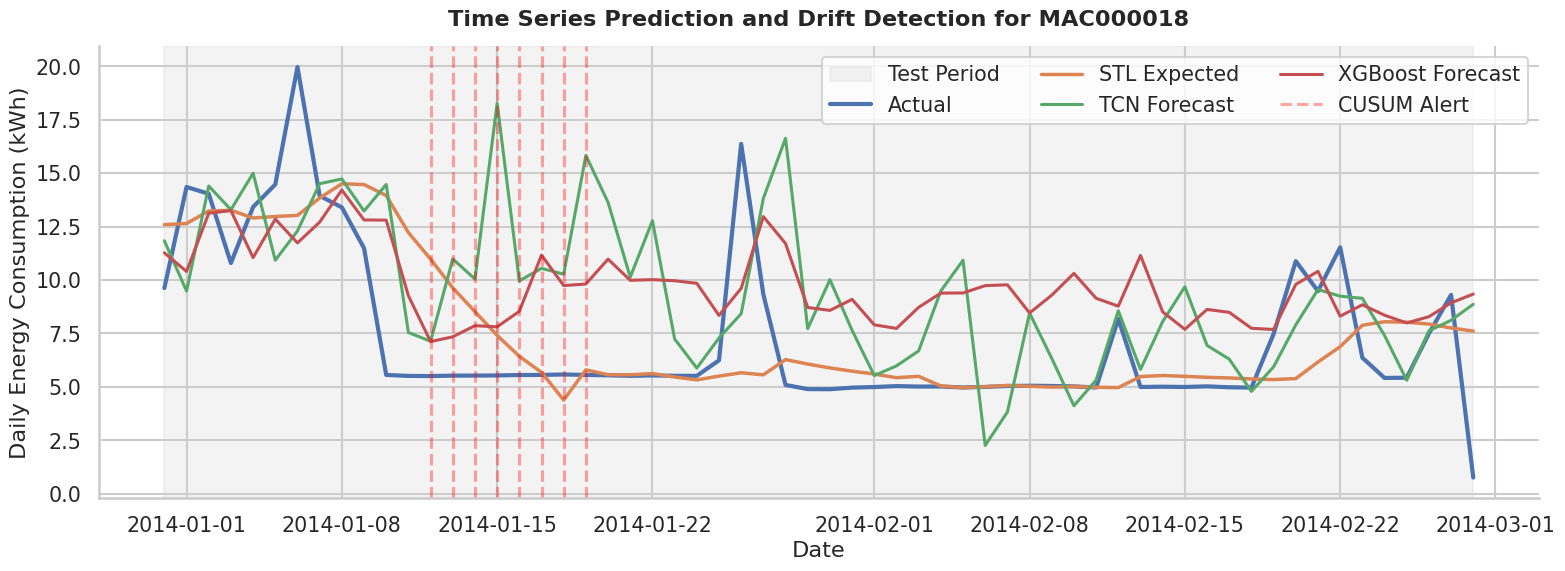

In [ ]:
house = best_house

stl_df = stl_details[house].copy()
tcn_df = tcn_details.get(house, None)
xgb_df = xgb_details.get(house, None)

fig, ax = plt.subplots(figsize=(16, 6))

ax.axvspan(test_start, stl_df["date"].max(), color="lightgrey", alpha=0.25, label="Test Period")

sns.lineplot(data=stl_df, x="date", y="daily_kWh", ax=ax, label="Actual", linewidth=3)
sns.lineplot(data=stl_df, x="date", y="expected_test", ax=ax, label="STL Expected", linewidth=2.5)

if tcn_df is not None:
    sns.lineplot(data=tcn_df, x="date", y="predicted", ax=ax, label="TCN Forecast", linewidth=2.2)

if xgb_df is not None:
    sns.lineplot(data=xgb_df, x="date", y="predicted", ax=ax, label="XGBoost Forecast", linewidth=2.2)

alert_dates = stl_df.loc[stl_df["cusum_alert"] == True, "date"]
for i, d in enumerate(alert_dates):
    ax.axvline(d, color="red", linestyle="--", alpha=0.35, label="CUSUM Alert" if i == 0 else "")

ax.set_title(f"Time Series Prediction and Drift Detection for {house}", weight="bold", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Daily Energy Consumption (kWh)")
ax.legend(ncol=3, frameon=True)
plt.tight_layout()
plt.show()

## **2. CUSUM vs EWMA Drift Plot**

**Best for method comparison**

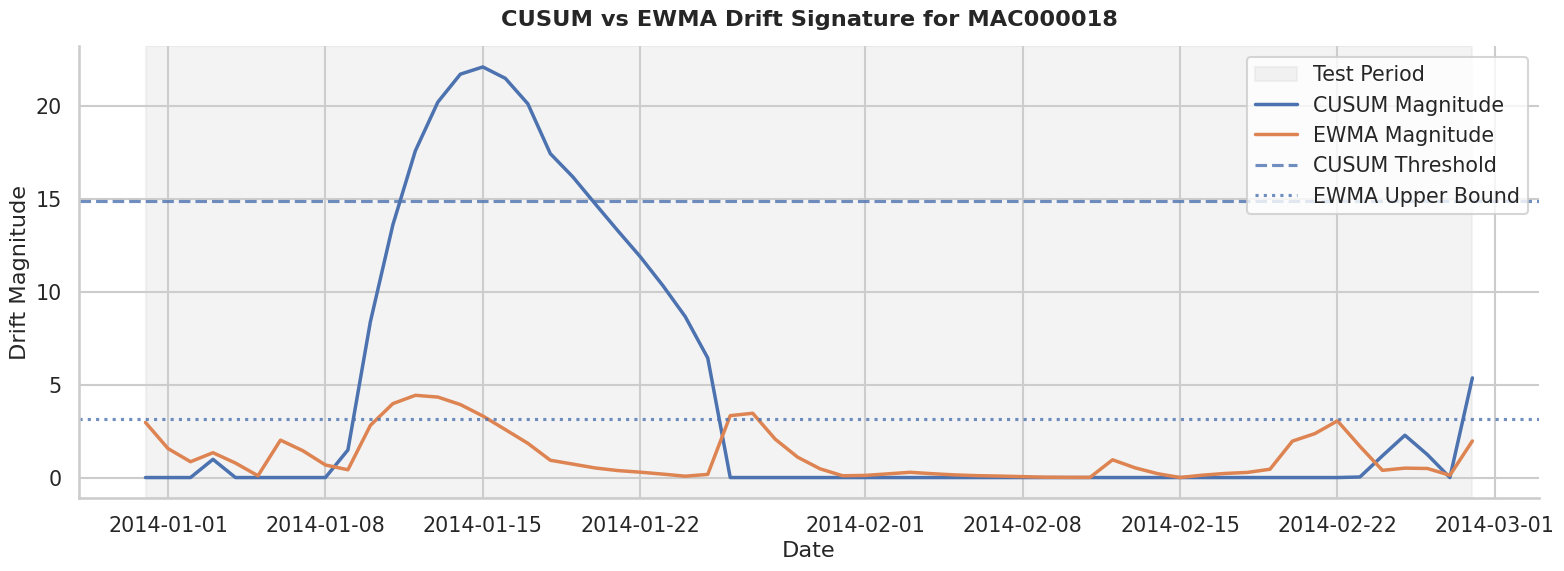

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.axvspan(test_start, stl_df["date"].max(), color="lightgrey", alpha=0.25, label="Test Period")

sns.lineplot(x=stl_df["date"], y=stl_df["cusum_neg"].abs(), ax=ax, label="CUSUM Magnitude", linewidth=2.5)
sns.lineplot(x=stl_df["date"], y=stl_df["ewma"].abs(), ax=ax, label="EWMA Magnitude", linewidth=2.5)

if "cusum_h" in stl_df.columns:
    ax.axhline(stl_df["cusum_h"].iloc[0], linestyle="--", alpha=0.8, label="CUSUM Threshold")

if "ewma_upper" in stl_df.columns:
    ax.axhline(abs(stl_df["ewma_upper"].iloc[0]), linestyle=":", alpha=0.8, label="EWMA Upper Bound")

ax.set_title(f"CUSUM vs EWMA Drift Signature for {house}", weight="bold", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Drift Magnitude")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## **3. Alert Heatmap**

**Multi-household comparison plot**

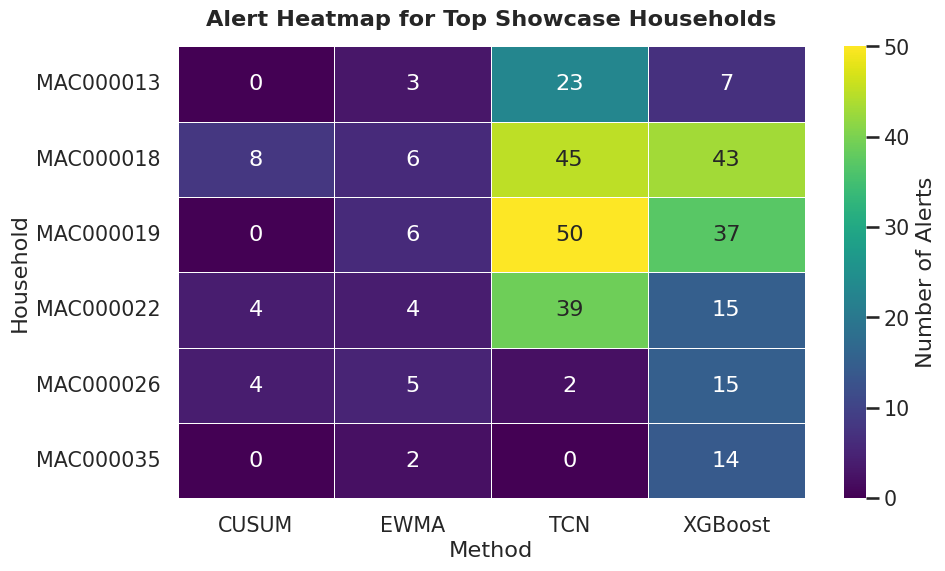

In [ ]:
compare_subset = comparison[comparison["LCLid"].isin(top_showcase_houses)].copy()

heatmap_df = compare_subset[[
    "LCLid",
    "cusum_num_alerts",
    "ewma_num_alerts",
    "tcn_num_alerts",
    "xgb_num_alerts"
]].copy()

heatmap_df.columns = ["LCLid", "CUSUM", "EWMA", "TCN", "XGBoost"]
heatmap_df = heatmap_df.set_index("LCLid")

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_df.fillna(0),
    annot=True,
    fmt=".0f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Number of Alerts"}
)
plt.title("Alert Heatmap for Top Showcase Households", weight="bold", pad=15)
plt.xlabel("Method")
plt.ylabel("Household")
plt.tight_layout()
plt.show()

## **4. Forecast Error Boxplot**

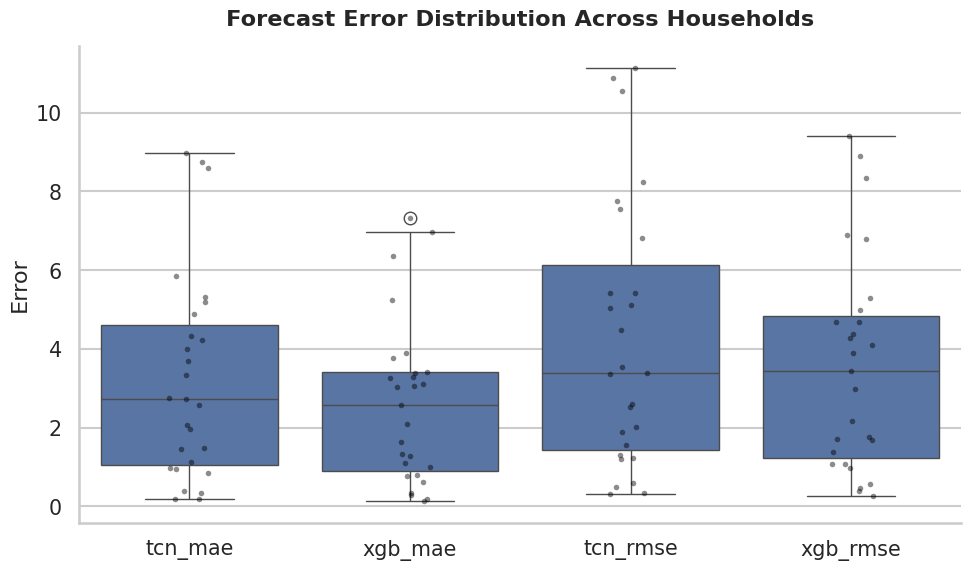

In [ ]:
error_long = comparison[["tcn_mae", "xgb_mae", "tcn_rmse", "xgb_rmse"]].copy()
error_long = error_long.melt(var_name="Metric", value_name="Value").dropna()

plt.figure(figsize=(10, 6))
sns.boxplot(data=error_long, x="Metric", y="Value")
sns.stripplot(data=error_long, x="Metric", y="Value", color="black", alpha=0.45, size=4)
plt.title("Forecast Error Distribution Across Households", weight="bold", pad=15)
plt.xlabel("")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

## **5. First Alert Timeline Plot**

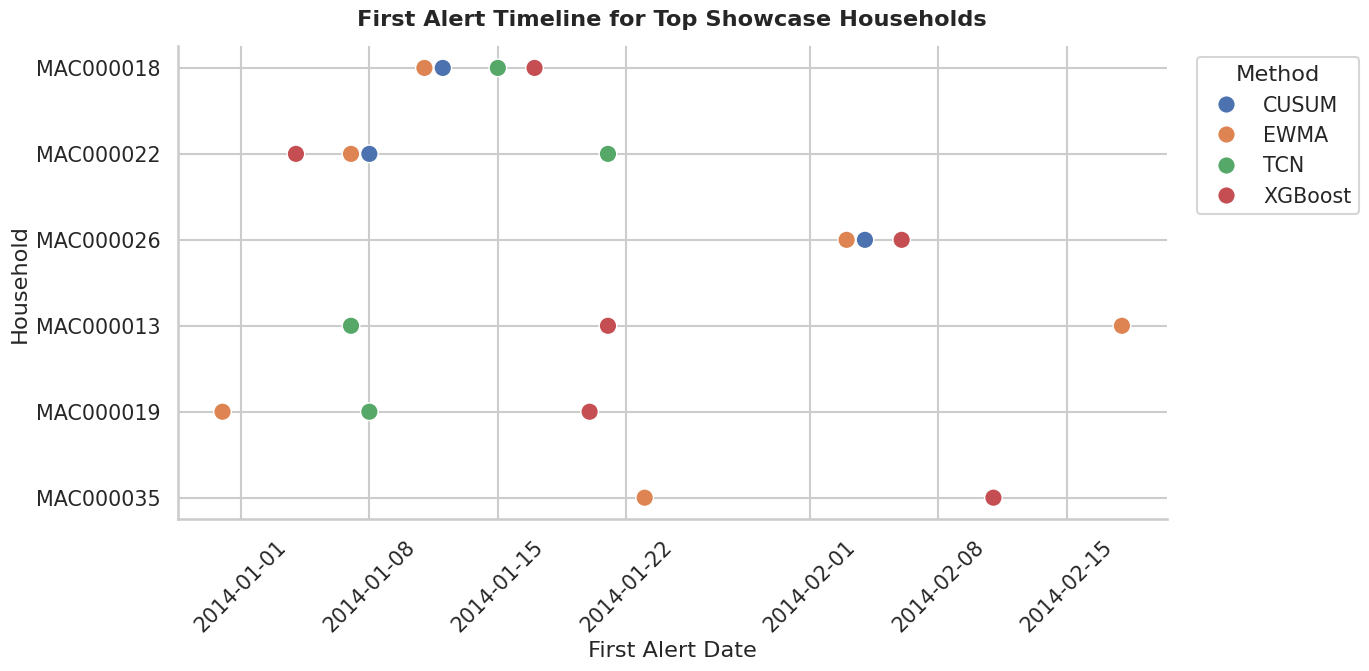

In [ ]:
timeline_df = compare_subset[[
    "LCLid",
    "cusum_first_alert",
    "ewma_first_alert",
    "tcn_first_alert",
    "xgb_first_alert"
]].copy()

timeline_long = timeline_df.melt(
    id_vars="LCLid",
    var_name="Method",
    value_name="FirstAlert"
).dropna()

timeline_long["Method"] = timeline_long["Method"].replace({
    "cusum_first_alert": "CUSUM",
    "ewma_first_alert": "EWMA",
    "tcn_first_alert": "TCN",
    "xgb_first_alert": "XGBoost"
})

plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=timeline_long,
    x="FirstAlert",
    y="LCLid",
    hue="Method",
    s=160
)
plt.title("First Alert Timeline for Top Showcase Households", weight="bold", pad=15)
plt.xlabel("First Alert Date")
plt.ylabel("Household")
plt.xticks(rotation=45)
plt.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## **6. Carbon vs Energy Drift Plot**

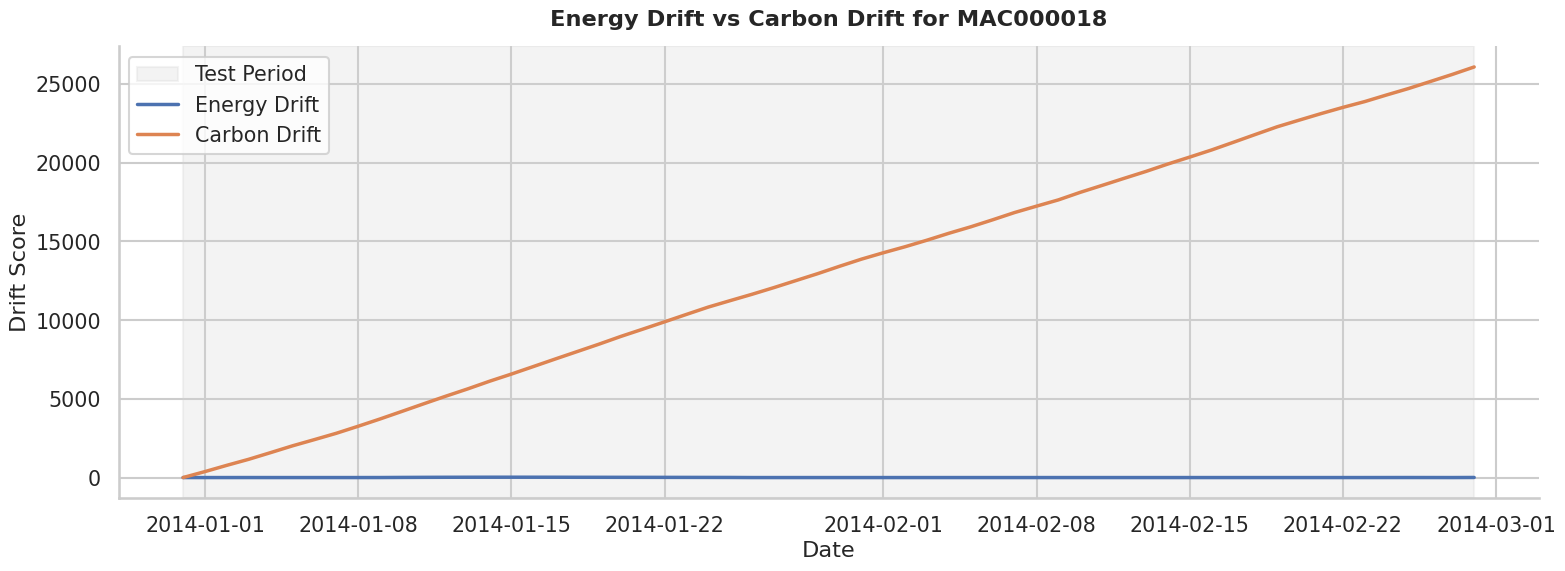

In [186]:
if "carbon_intensity" in merged2.columns:
    carbon_df = merged2[merged2["LCLid"] == house][["date", "carbon_intensity"]].copy()
    carbon_df = carbon_df[carbon_df["date"] >= test_start].dropna()

    c = carbon_df["carbon_intensity"].fillna(0).values
    carbon_cusum_pos, _, _, _, _ = cusum_drift(c)

    carbon_plot_df = pd.DataFrame({
        "date": carbon_df["date"].values,
        "carbon_drift": carbon_cusum_pos
    })

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.axvspan(test_start, stl_df["date"].max(), color="lightgrey", alpha=0.25, label="Test Period")

    sns.lineplot(x=stl_df["date"], y=stl_df["cusum_neg"].abs(), ax=ax, label="Energy Drift", linewidth=2.5)
    sns.lineplot(data=carbon_plot_df, x="date", y="carbon_drift", ax=ax, label="Carbon Drift", linewidth=2.5)

    ax.set_title(f"Energy Drift vs Carbon Drift for {house}", weight="bold", pad=15)
    ax.set_xlabel("Date")
    ax.set_ylabel("Drift Score")
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()

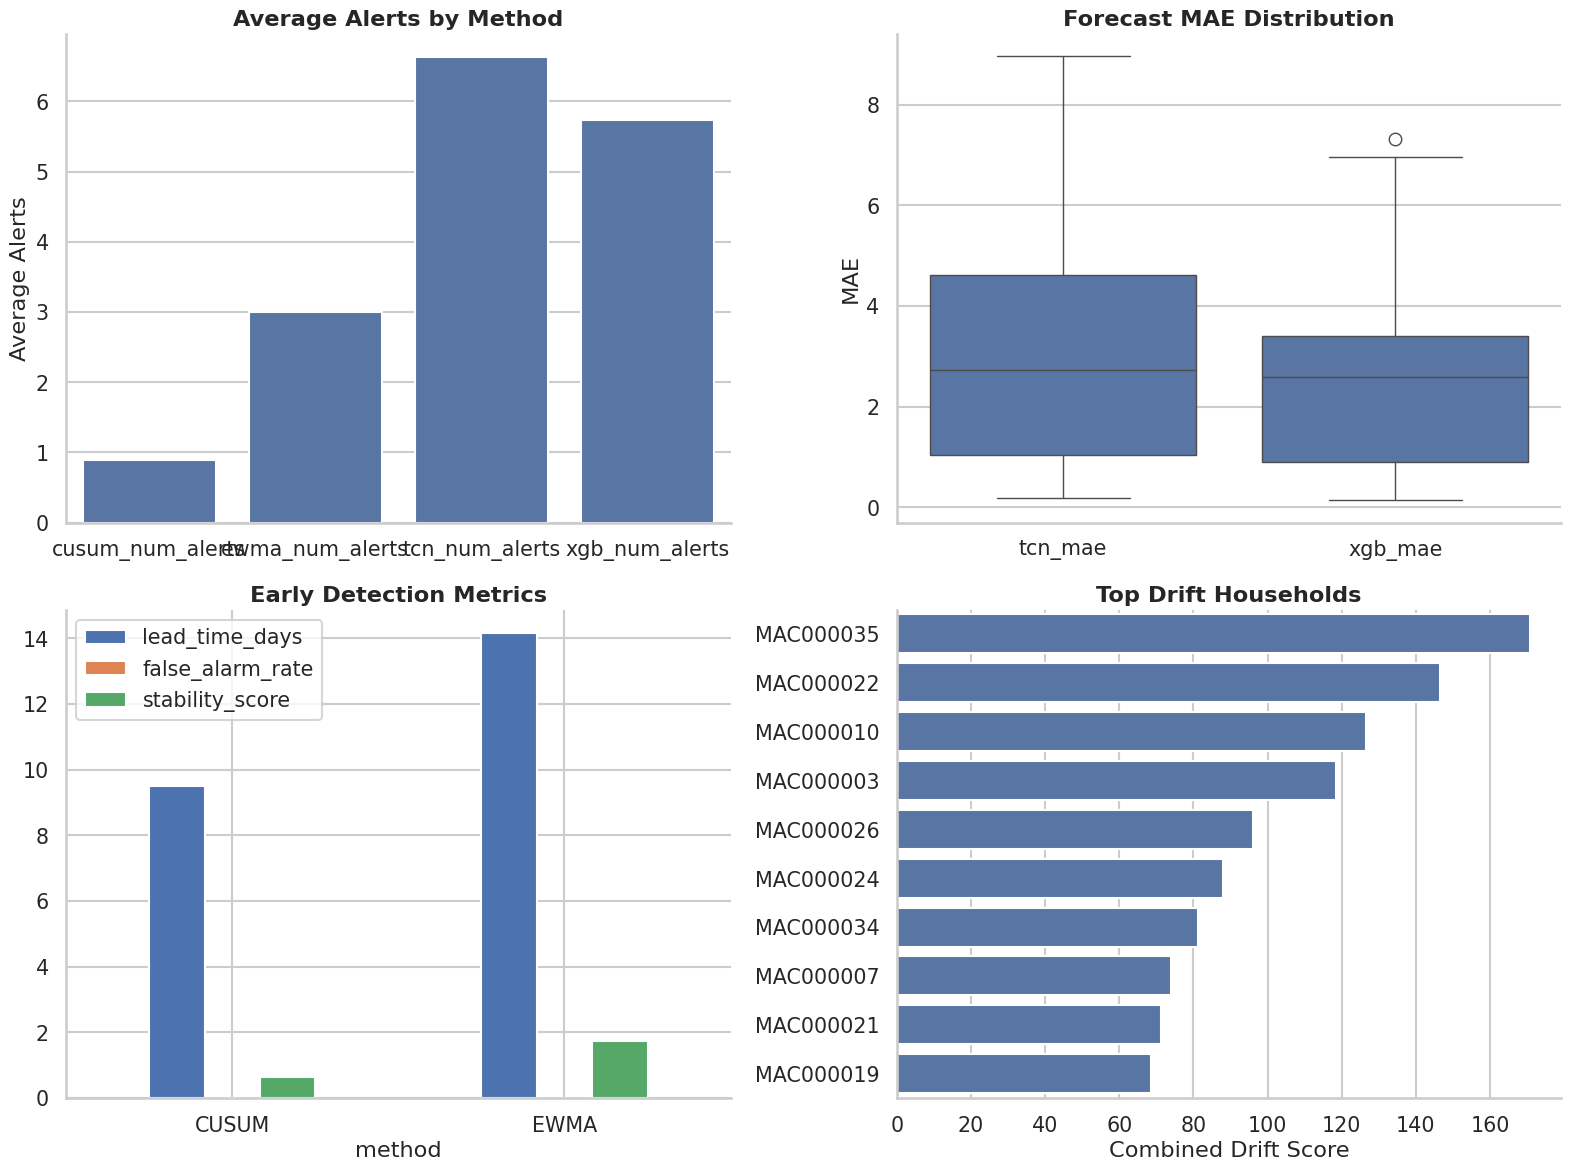

In [ ]:
rank_df = comparison[["LCLid", "cusum_max_drift", "ewma_max_drift", "tcn_max_drift", "xgb_max_drift"]].copy()
rank_df = rank_df.fillna(0)
rank_df["total_drift_score"] = rank_df[[
    "cusum_max_drift", "ewma_max_drift", "tcn_max_drift", "xgb_max_drift"
]].sum(axis=1)
rank_df = rank_df.sort_values("total_drift_score", ascending=False).head(10)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

avg_alerts = comparison[["cusum_num_alerts", "ewma_num_alerts", "tcn_num_alerts", "xgb_num_alerts"]].mean()
sns.barplot(x=avg_alerts.index, y=avg_alerts.values, ax=axes[0, 0])
axes[0, 0].set_title("Average Alerts by Method", weight="bold")
axes[0, 0].set_ylabel("Average Alerts")
axes[0, 0].set_xlabel("")


mae_df = comparison[["tcn_mae", "xgb_mae"]].melt(var_name="Model", value_name="MAE").dropna()
sns.boxplot(data=mae_df, x="Model", y="MAE", ax=axes[0, 1])
axes[0, 1].set_title("Forecast MAE Distribution", weight="bold")
axes[0, 1].set_xlabel("")

eval_bar = early_eval.groupby("method")[["lead_time_days", "false_alarm_rate", "stability_score"]].mean(numeric_only=True)
eval_bar.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Early Detection Metrics", weight="bold")
axes[1, 0].tick_params(axis="x", rotation=0)

sns.barplot(data=rank_df, x="total_drift_score", y="LCLid", ax=axes[1, 1])
axes[1, 1].set_title("Top Drift Households", weight="bold")
axes[1, 1].set_xlabel("Combined Drift Score")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()